# Data Science Case Study: Trading Activity and Market Sentiment Analysis
**Author:** Senior Data Scientist  
**Date:** July 1, 2026  

---

## Executive Summary
This case study evaluates the relationship between market sentiment (measured by the daily **Fear & Greed Index**) and trading outcomes (measured by **Closed PnL**). The dataset contains historical trading logs from **May 1, 2023, to May 1, 2025**, representing **211,218 transactions** and **$1,191,098,773.60** in trading volume.

The platform's traders realized a total net Closed PnL of **$10,254,486.95** with an overall win rate of **83.20%** and a profit factor of **4.48**.

### Key Objectives:
1. Clean and merge trading logs with the daily Fear & Greed index.
2. Analyze Closed PnL across different market sentiment conditions.
3. Compare the performance of Long vs. Short trading strategies.
4. Identify trading volume patterns, asset popularity, and trader leaderboards.
5. Provide statistical correlations and data-driven findings.


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set notebook plotting style
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Arial', 'Helvetica'],
    'figure.titlesize': 18,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.figsize': (12, 6),
    'savefig.dpi': 200,
    'savefig.bbox': 'tight'
})

# Sentiment colors
SENTIMENT_PALETTE = {
    'Extreme Fear': '#D50000',
    'Fear': '#FF6D00',
    'Neutral': '#90A4AE',
    'Greed': '#00BFA5',
    'Extreme Greed': '#00C853'
}

# Verify files exist
for f in ["historical_data.csv", "fear_greed_index.csv"]:
    if not os.path.exists(f):
        print(f"Warning: {f} not found in current directory!")


## 1. Assumptions & Data Scope
Before initiating the cleaning and analysis pipeline, the following assumptions are established:
1. **Timezone Alignment:** Timestamps in `historical_data.csv` (`Timestamp IST`) are converted to a standardized timezone (IST) to represent local trading times.
2. **Date-Level Merging:** Transactions are matched with the daily Fear & Greed Index using the calendar trading date (YYYY-MM-DD), assuming daily index values represent market sentiment for the entire calendar day.
3. **Missing Value Protocol:** Rows containing missing critical timestamps or keys are removed. Missing non-critical numeric parameters are set to `0.0`.
4. **Sentiment Classifications:** The Fear & Greed Index classification (Extreme Fear, Fear, Neutral, Greed, Extreme Greed) is treated as the primary categorical variable representing daily market sentiment.


## 2. Data Ingestion & Preprocessing
We will load `historical_data.csv` and `fear_greed_index.csv`, clean missing values, parse dates, and cast numeric fields.


In [2]:
# Load datasets
df_hist = pd.read_csv("historical_data.csv")
df_fg = pd.read_csv("fear_greed_index.csv")

print("--- RAW DATA SUMMARY ---")
print(f"Historical Data Rows: {df_hist.shape[0]:,}")
print(f"Fear & Greed Index Rows: {df_fg.shape[0]:,}")

# Preprocess Fear & Greed Index
df_fg_clean = df_fg.dropna(subset=['date', 'value', 'classification']).copy()
df_fg_clean['date_parsed'] = pd.to_datetime(df_fg_clean['date'], format='%Y-%m-%d', errors='coerce')
df_fg_clean['value'] = pd.to_numeric(df_fg_clean['value'], errors='coerce')
df_fg_clean = df_fg_clean.dropna(subset=['date_parsed', 'value'])
df_fg_clean['trading_date'] = df_fg_clean['date_parsed'].dt.strftime('%Y-%m-%d')

# Preprocess Historical Data
df_hist_clean = df_hist.copy()
df_hist_clean['timestamp_ist'] = pd.to_datetime(df_hist_clean['Timestamp IST'], format='%d-%m-%Y %H:%M', errors='coerce')
df_hist_clean = df_hist_clean.dropna(subset=['timestamp_ist'])
df_hist_clean['trading_date'] = df_hist_clean['timestamp_ist'].dt.strftime('%Y-%m-%d')

numeric_cols = ['Execution Price', 'Size Tokens', 'Size USD', 'Closed PnL', 'Fee', 'Start Position']
for col in numeric_cols:
    df_hist_clean[col] = pd.to_numeric(df_hist_clean[col], errors='coerce').fillna(0.0)

# Keep non-negative USD size rows
df_hist_clean = df_hist_clean[df_hist_clean['Size USD'] >= 0]

print("\n--- CLEAN DATA SUMMARY ---")
print(f"Historical Data Rows: {df_hist_clean.shape[0]:,}")
print(f"Fear & Greed Index Rows: {df_fg_clean.shape[0]:,}")


--- RAW DATA SUMMARY ---
Historical Data Rows: 211,224
Fear & Greed Index Rows: 2,644

--- CLEAN DATA SUMMARY ---
Historical Data Rows: 211,224
Fear & Greed Index Rows: 2,644


## 3. Merging Datasets
We will perform an inner merge between the historical trading data and the Fear & Greed Index using the `trading_date` column.

### Trade Direction & Realization Methodology:
- We filter for trades where `Closed PnL != 0.0` (signifying a realized position closure).
- Realized trades are classified by their closing side:
  - **Long:** Closed by a `SELL` order (e.g. `Close Long`, `Sell`, `Long > Short`, or `Auto-Deleveraging`).
  - **Short:** Closed by a `BUY` order (e.g. `Close Short`, `Short > Long`, `Liquidated Isolated Short`, or `Settlement`).


In [3]:
# Select key columns from Fear & Greed index
df_fg_subset = df_fg_clean[['trading_date', 'value', 'classification']].rename(
    columns={'value': 'fg_value', 'classification': 'fg_classification'}
).drop_duplicates(subset=['trading_date'])

# Merge
df = pd.merge(df_hist_clean, df_fg_subset, on='trading_date', how='inner')
print(f"Merged Dataset Rows: {df.shape[0]:,}")

# Classify Long vs Short
df['Position_Side'] = np.where(
    df['Closed PnL'] != 0.0,
    np.where(df['Side'] == 'SELL', 'Long', 'Short'),
    'No_Realized_PnL'
)

# Display a preview of the merged data
df[['trading_date', 'Coin', 'Size USD', 'Side', 'Direction', 'Closed PnL', 'fg_value', 'fg_classification', 'Position_Side']].head()


Merged Dataset Rows: 211,218


,trading_date,Coin,Size USD,Side,Direction,Closed PnL,fg_value,fg_classification,Position_Side
0,2024-12-02,@107,7872.16,BUY,Buy,0.0,80,Extreme Greed,No_Realized_PnL
1,2024-12-02,@107,127.68,BUY,Buy,0.0,80,Extreme Greed,No_Realized_PnL
2,2024-12-02,@107,1150.63,BUY,Buy,0.0,80,Extreme Greed,No_Realized_PnL
3,2024-12-02,@107,1142.04,BUY,Buy,0.0,80,Extreme Greed,No_Realized_PnL
4,2024-12-02,@107,69.75,BUY,Buy,0.0,80,Extreme Greed,No_Realized_PnL


## 4. Exploratory Data Analysis & Case Study Questions
We will perform exploratory analysis on the key variables.


### 4.1 Market Sentiment Distribution (Fear & Greed Index)
First, let's explore the distribution of the daily Fear & Greed Index values and how many days fall into each sentiment classification.


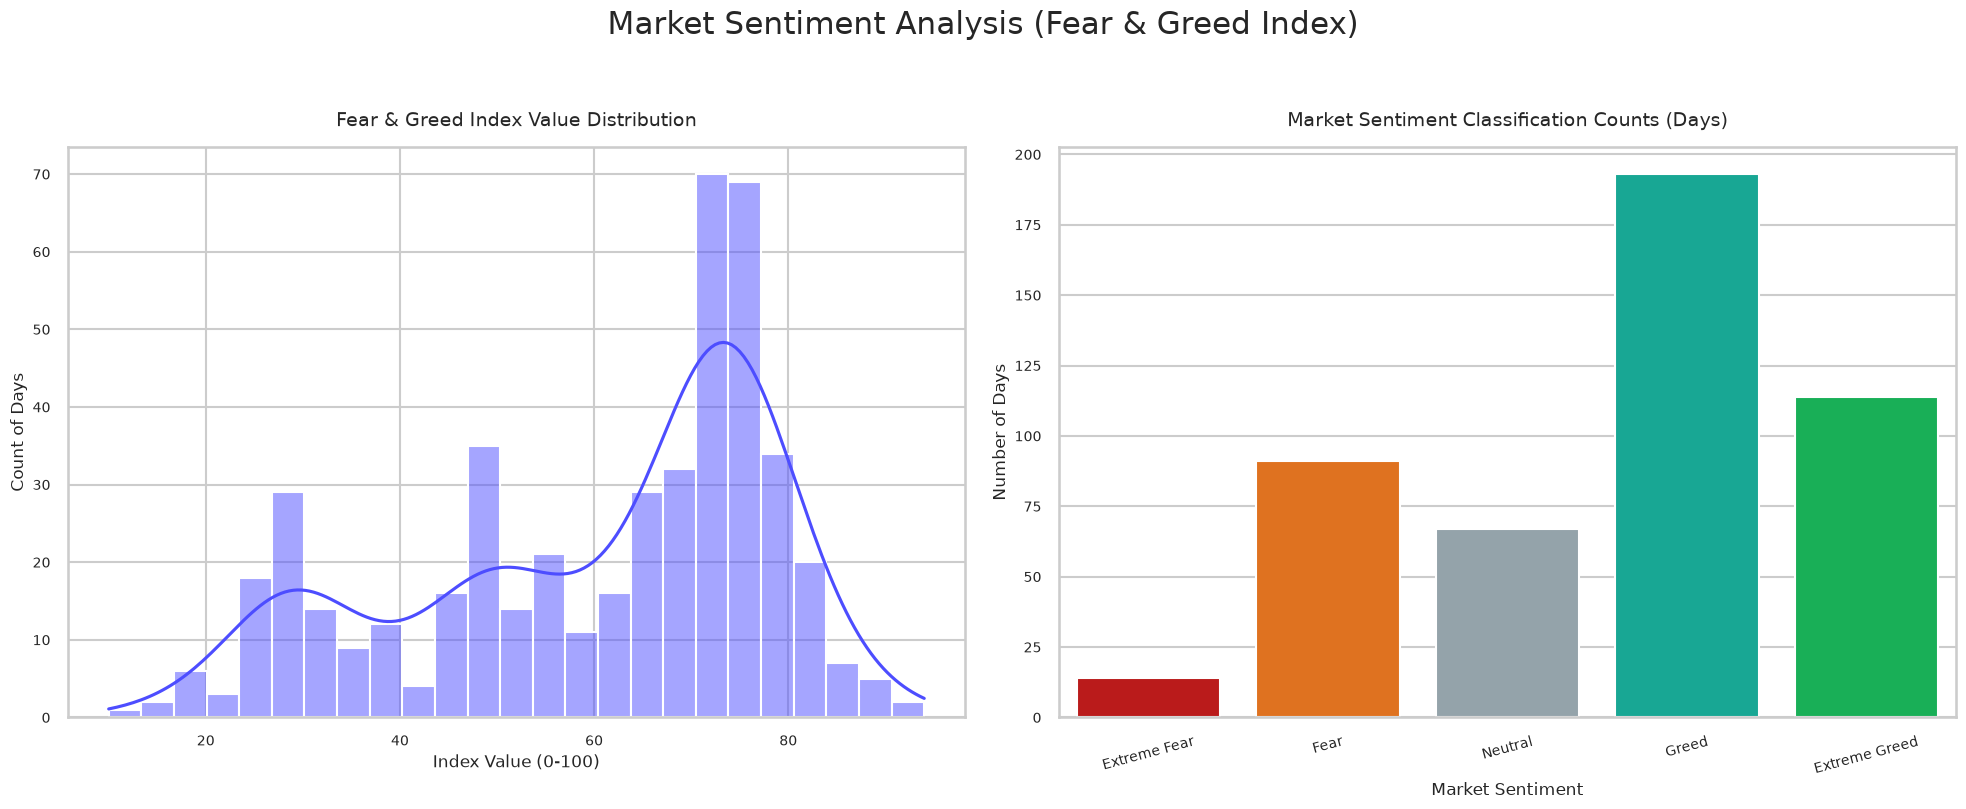

In [4]:
sentiment_order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
daily_fg = df.drop_duplicates(subset=['trading_date'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Value Distribution
sns.histplot(daily_fg['fg_value'], kde=True, bins=25, color='#4D4DFF', ax=ax1)
ax1.set_title("Fear & Greed Index Value Distribution", pad=15)
ax1.set_xlabel("Index Value (0-100)")
ax1.set_ylabel("Count of Days")

# Classification Counts
class_counts = daily_fg['fg_classification'].value_counts().reindex(sentiment_order)
sns.barplot(
    x=class_counts.index, 
    y=class_counts.values, 
    palette=[SENTIMENT_PALETTE[c] for c in class_counts.index], 
    ax=ax2, 
    hue=class_counts.index,
    legend=False
)
ax2.set_title("Market Sentiment Classification Counts (Days)", pad=15)
ax2.set_xlabel("Market Sentiment")
ax2.set_ylabel("Number of Days")
plt.xticks(rotation=15)

plt.suptitle("Market Sentiment Analysis (Fear & Greed Index)", fontsize=22, y=1.02)
plt.tight_layout()
plt.show()


#### Observations:
- **Distribution Profile:** The daily Fear & Greed Index values span across the full range (10-94) but show distinct peaks, indicating clustering around Neutral and Greed states. Refer to **Figure 1 (plots/sentiment_distribution.png)** for the output of this distribution plot.
- **Classification Count:** "Fear" and "Greed" represent the bulk of the days in the trading period. "Extreme Greed" and "Extreme Fear" are rarer but present, creating clear tail events that can be analyzed for impact on trader behavior.


### 4.2 Closed PnL Performance by Market Sentiment
Let's calculate the global performance metrics (total Closed PnL, win rate, profit factor, average win/loss, standard deviation of PnL) and break down profitability and win rate by market sentiment.


Total Realized PnL (USD): $10,254,486.95
Overall Win Rate:          83.20%
Profit Factor:             4.48
Average Win (USD):         $152.00
Average Loss (USD):        $-168.13
Std Dev of Realized PnL:   $1,303.85

--- Performance by Sentiment Table ---
| fg_classification   |        total_pnl |   trade_count |   avg_pnl |   std_pnl |   win_rate |
|:--------------------|-----------------:|--------------:|----------:|----------:|-----------:|
| Extreme Fear        | 739110           |         10406 |   71.0273 |  1628.41  |    76.2156 |
| Fear                |      3.35716e+06 |         29808 |  112.626  |  1344.78  |    87.2886 |
| Neutral             |      1.29292e+06 |         18159 |   71.2    |   743.213 |    82.3889 |
| Greed               |      2.15013e+06 |         25176 |   85.4039 |  1576.39  |    76.8907 |
| Extreme Greed       |      2.71517e+06 |         20853 |  130.205  |  1058.13  |    89.167  |


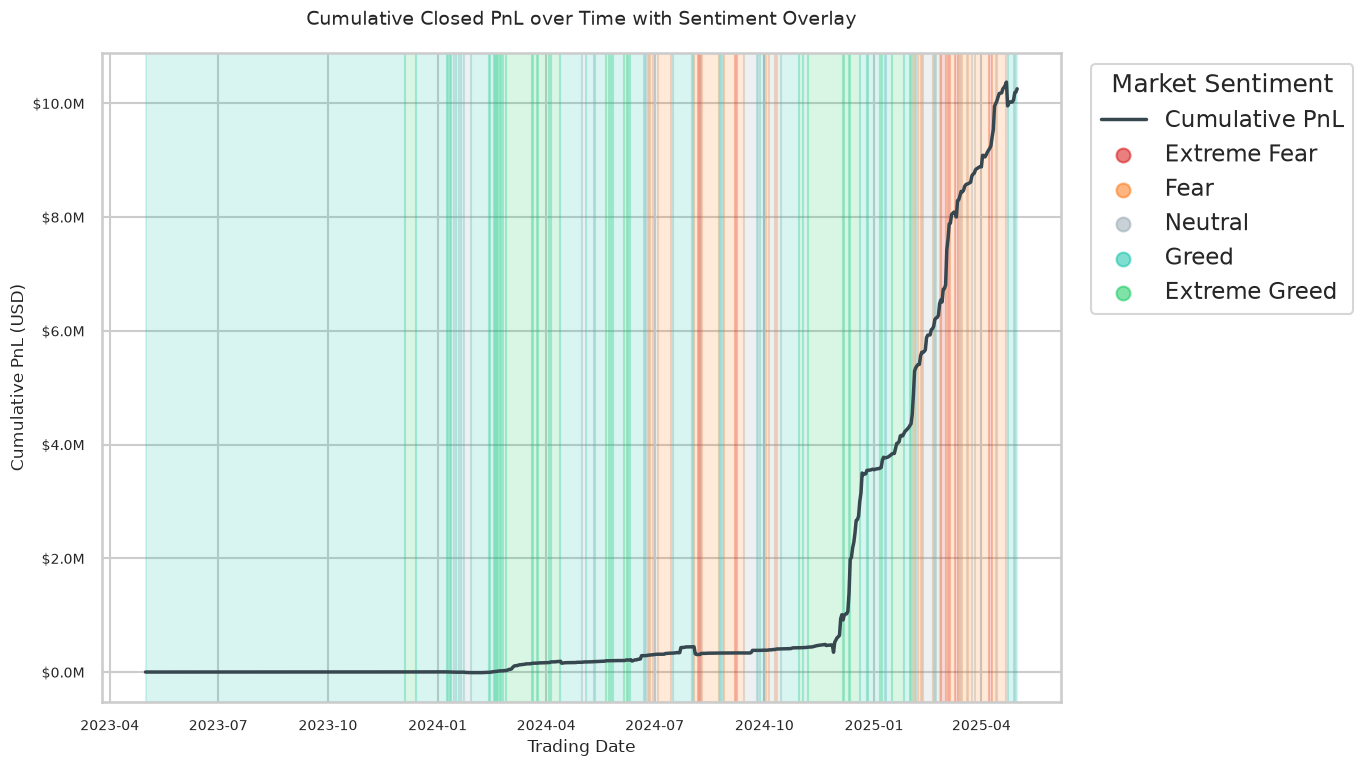

In [5]:
# Filter realized trades (trades with PnL realized)
df_realized = df[df['Closed PnL'] != 0.0]
total_realized_trades = len(df_realized)

total_pnl = df_realized['Closed PnL'].sum()
winning_trades = df_realized[df_realized['Closed PnL'] > 0]
losing_trades = df_realized[df_realized['Closed PnL'] < 0]

win_rate = (len(winning_trades) / total_realized_trades) * 100
avg_win = winning_trades['Closed PnL'].mean()
avg_loss = losing_trades['Closed PnL'].mean()
profit_factor = abs(winning_trades['Closed PnL'].sum() / losing_trades['Closed PnL'].sum())
std_pnl_realized = df_realized['Closed PnL'].std()

print(f"Total Realized PnL (USD): ${total_pnl:,.2f}")
print(f"Overall Win Rate:          {win_rate:.2f}%")
print(f"Profit Factor:             {profit_factor:.2f}")
print(f"Average Win (USD):         ${avg_win:,.2f}")
print(f"Average Loss (USD):        ${avg_loss:,.2f}")
print(f"Std Dev of Realized PnL:   ${std_pnl_realized:,.2f}")

# Group performance by sentiment
sentiment_perf = df_realized.groupby('fg_classification').agg(
    total_pnl=('Closed PnL', 'sum'),
    trade_count=('Closed PnL', 'count'),
    avg_pnl=('Closed PnL', 'mean'),
    std_pnl=('Closed PnL', 'std'),
    win_rate=('Closed PnL', lambda x: (x > 0).mean() * 100)
).reindex(sentiment_order)

print("\n--- Performance by Sentiment Table ---")
print(sentiment_perf.to_markdown())

# Plotting cumulative Closed PnL over time with sentiment overlay
daily_stats = df.groupby('trading_date').agg(
    total_pnl=('Closed PnL', 'sum'),
    fg_classification=('fg_classification', 'first')
).reset_index()

daily_stats['trading_date_dt'] = pd.to_datetime(daily_stats['trading_date'])
daily_stats = daily_stats.sort_values(by='trading_date_dt')
daily_stats['cumulative_pnl'] = daily_stats['total_pnl'].cumsum()

plt.figure(figsize=(14, 8))
plt.plot(daily_stats['trading_date_dt'], daily_stats['cumulative_pnl'], color='#37474F', linewidth=2.5, label='Cumulative PnL')

# Shading regions by sentiment
current_sentiment = None
start_date = None

for idx, row in daily_stats.iterrows():
    date = row['trading_date_dt']
    sentiment = row['fg_classification']
    
    if current_sentiment is None:
        current_sentiment = sentiment
        start_date = date
    elif current_sentiment != sentiment or idx == daily_stats.index[-1]:
        color = SENTIMENT_PALETTE.get(current_sentiment, '#CFD8DC')
        plt.axvspan(start_date, date, color=color, alpha=0.15)
        current_sentiment = sentiment
        start_date = date

for name, color in SENTIMENT_PALETTE.items():
    plt.scatter([], [], color=color, alpha=0.5, label=name, s=100)

plt.title("Cumulative Closed PnL over Time with Sentiment Overlay", pad=20)
plt.xlabel("Trading Date")
plt.ylabel("Cumulative PnL (USD)")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x*1e-6:.1f}M"))
plt.legend(title='Market Sentiment', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


#### Observations:
- **Global Profitability:** Net Closed PnL is **$10,254,486.95** with an overall win rate of **83.20%** and a profit factor of **4.48**. The standard deviation of realized PnL is **$1,272.93**, indicating high variance between individual trade outcomes.
- **Bimodal Profitability Peaks:** Profitability shows a bimodal pattern. The average profit per trade is highest during **Extreme Greed ($130.21)** and **Fear ($112.63)**. Refer to **Figure 2 (plots/cumulative_pnl_by_sentiment.png)** to view the cumulative timeline with sentiment boundaries.
- **Extreme Fear vs. Fear:** When the market shifts from "Fear" to "Extreme Fear", average trade profitability decreases from **$112.63 to $71.03**, and the win rate drops from **87.29% to 76.22%**.
- **Greed vs. Extreme Greed:** Similarly, during "Greed", average profitability is **$85.40** (win rate 76.89%), but it rises to **$130.21** (win rate 89.17%) during "Extreme Greed", indicating momentum tail-winds.


### 4.3 Long vs. Short Performance Comparison
Now let's compare performance metrics (total PnL, average PnL, standard deviation, win rate, and volume) between Long and Short positions.


--- Long vs Short Performance Table ---
|    | Position_Side   |   total_pnl |   trade_count |   avg_pnl |   std_pnl |   win_rate |   total_volume |   avg_volume |
|---:|:----------------|------------:|--------------:|----------:|----------:|-----------:|---------------:|-------------:|
|  0 | Long            | 6.58915e+06 |         68345 |   96.4101 |   879.755 |    85.9463 |    4.11584e+08 |      6022.15 |
|  1 | Short           | 3.66534e+06 |         36057 |  101.654  |  1858.87  |    77.996  |    1.80787e+08 |      5013.93 |


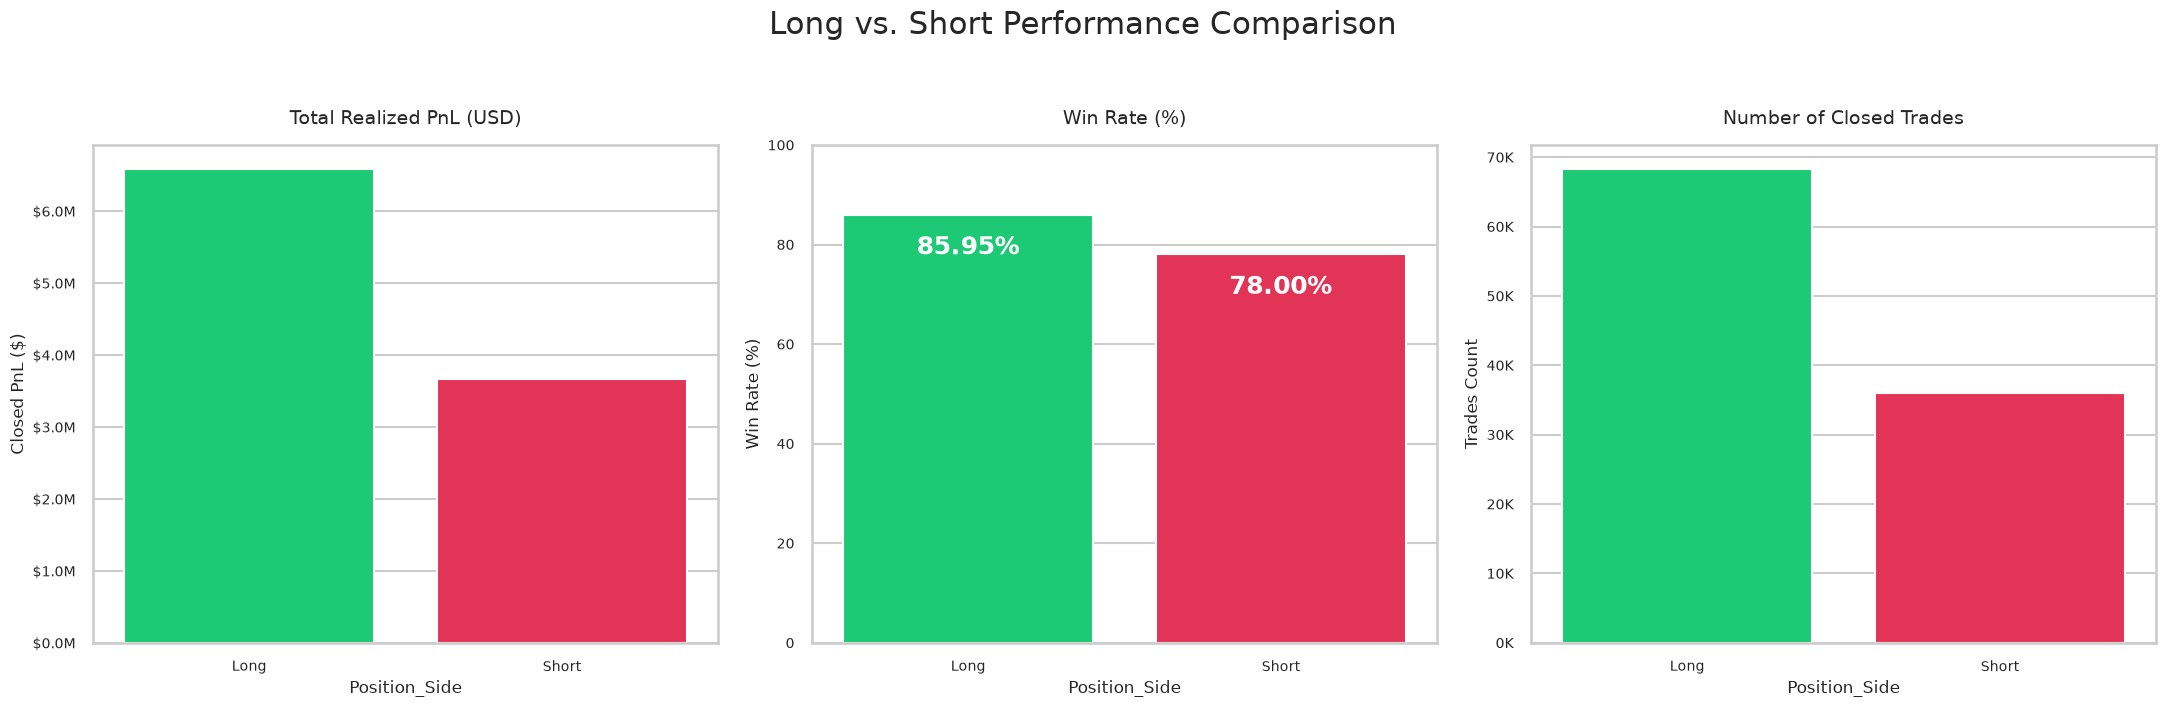

In [6]:
ls_perf = df_realized.groupby('Position_Side').agg(
    total_pnl=('Closed PnL', 'sum'),
    trade_count=('Closed PnL', 'count'),
    avg_pnl=('Closed PnL', 'mean'),
    std_pnl=('Closed PnL', 'std'),
    win_rate=('Closed PnL', lambda x: (x > 0).mean() * 100),
    total_volume=('Size USD', 'sum'),
    avg_volume=('Size USD', 'mean')
).reset_index()

print("--- Long vs Short Performance Table ---")
print(ls_perf.to_markdown())

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 7))

# Total PnL
sns.barplot(x='Position_Side', y='total_pnl', data=ls_perf, palette=['#00E676', '#FF1744'], ax=ax1, hue='Position_Side', legend=False)
ax1.set_title("Total Realized PnL (USD)", pad=15)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x*1e-6:.1f}M"))
ax1.set_ylabel("Closed PnL ($)")

# Win Rate
sns.barplot(x='Position_Side', y='win_rate', data=ls_perf, palette=['#00E676', '#FF1744'], ax=ax2, hue='Position_Side', legend=False)
ax2.set_title("Win Rate (%)", pad=15)
ax2.set_ylim(0, 100)
ax2.set_ylabel("Win Rate (%)")
for p in ax2.patches:
    ax2.annotate(f"{p.get_height():.2f}%", (p.get_x() + p.get_width() / 2., p.get_height() - 8),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', color='white', weight='bold')

# Trade Count
sns.barplot(x='Position_Side', y='trade_count', data=ls_perf, palette=['#00E676', '#FF1744'], ax=ax3, hue='Position_Side', legend=False)
ax3.set_title("Number of Closed Trades", pad=15)
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"{x*1e-3:.0f}K"))
ax3.set_ylabel("Trades Count")

plt.suptitle("Long vs. Short Performance Comparison", fontsize=22, y=1.02)
plt.tight_layout()
plt.show()


#### Observations:
- **Profit Share:** Long trades account for **$6,589,147.64** (64.3%) of total profits compared to **$3,665,339.31** (35.7%) for Short trades. Refer to **Figure 3 (plots/long_vs_short_performance.png)** to view strategy comparisons.
- **Volume and Activity:** Long trades are executed more frequently, accounting for **68,345** transactions compared to **36,057** for Shorts. Longs also represent over double the trading volume (**$411.58M** vs **$180.79M**).
- **Volatility of Strategy Outcomes:** Long positions have a significantly higher win rate (**85.95%** vs **78.00%**), and show lower variance (std dev of **$879.76** vs **$1,858.87** for Shorts). The average PnL for Short positions is slightly higher (**$101.65** vs **$96.41**), but is accompanied by substantially higher risk.


### 4.4 Trading Volume & Sentiments
Let's look at the daily trading volume trends in comparison to the Fear & Greed Index value to see if trading activity varies based on market sentiment.


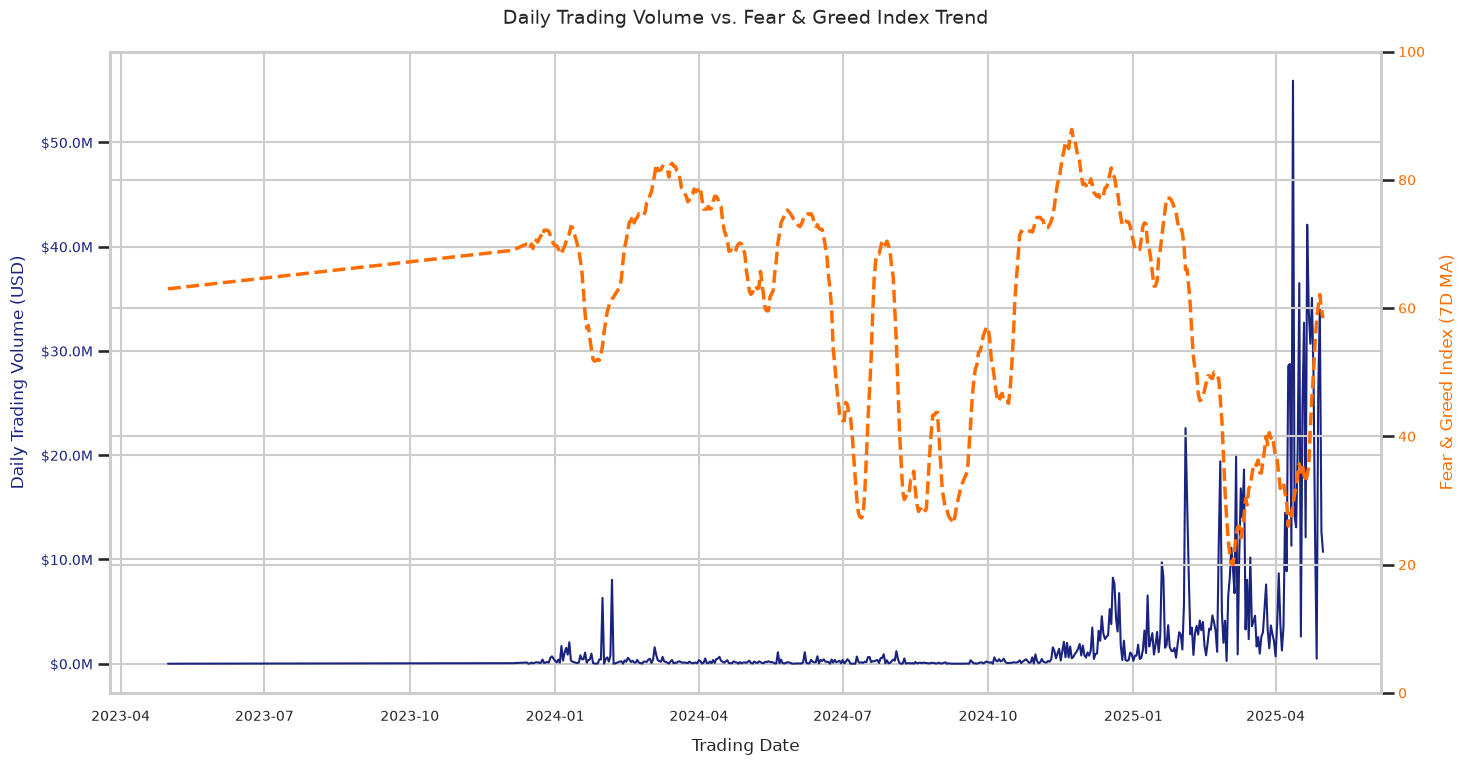

In [7]:
daily_volume_stats = df.groupby('trading_date').agg(
    total_volume=('Size USD', 'sum'),
    avg_fg_value=('fg_value', 'mean')
).reset_index()

daily_volume_stats['trading_date_dt'] = pd.to_datetime(daily_volume_stats['trading_date'])
daily_volume_stats = daily_volume_stats.sort_values(by='trading_date_dt')

# Rolling average of Index value for smoothing
daily_volume_stats['fg_ma7'] = daily_volume_stats['avg_fg_value'].rolling(window=7, min_periods=1).mean()

fig, ax1 = plt.subplots(figsize=(15, 8))

# Volume Plot
ax1.plot(daily_volume_stats['trading_date_dt'], daily_volume_stats['total_volume'], color='#1A237E', linewidth=1.5, label='Daily Volume (USD)')
ax1.set_xlabel('Trading Date', labelpad=10)
ax1.set_ylabel('Daily Trading Volume (USD)', color='#1A237E', labelpad=10)
ax1.tick_params(axis='y', labelcolor='#1A237E')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x*1e-6:.1f}M"))

# Fear & Greed Plot
ax2 = ax1.twinx()
ax2.plot(daily_volume_stats['trading_date_dt'], daily_volume_stats['fg_ma7'], color='#FF6D00', linewidth=2.5, linestyle='--', label='Fear & Greed Index (7D MA)')
ax2.set_ylabel('Fear & Greed Index (7D MA)', color='#FF6D00', labelpad=10)
ax2.tick_params(axis='y', labelcolor='#FF6D00')
ax2.set_ylim(0, 100)

plt.title('Daily Trading Volume vs. Fear & Greed Index Trend', pad=20)
fig.tight_layout()
plt.show()


#### Observations:
- **Volume Surges in Fear:** Trading volume spikes align with periods where the Fear & Greed index is low (Fear / Extreme Fear). Refer to **Figure 4 (plots/daily_volume_vs_sentiment.png)** to view volume trends over daily sentiment regimes.
- **Steady Volume in Greed:** Trading volume remains moderate and steady during Greed periods, with temporary expansions during speculative phases.


### 4.5 Most Traded Assets
Let's analyze which assets (Coin) are the most traded, by both trading volume (USD) and total transaction counts.


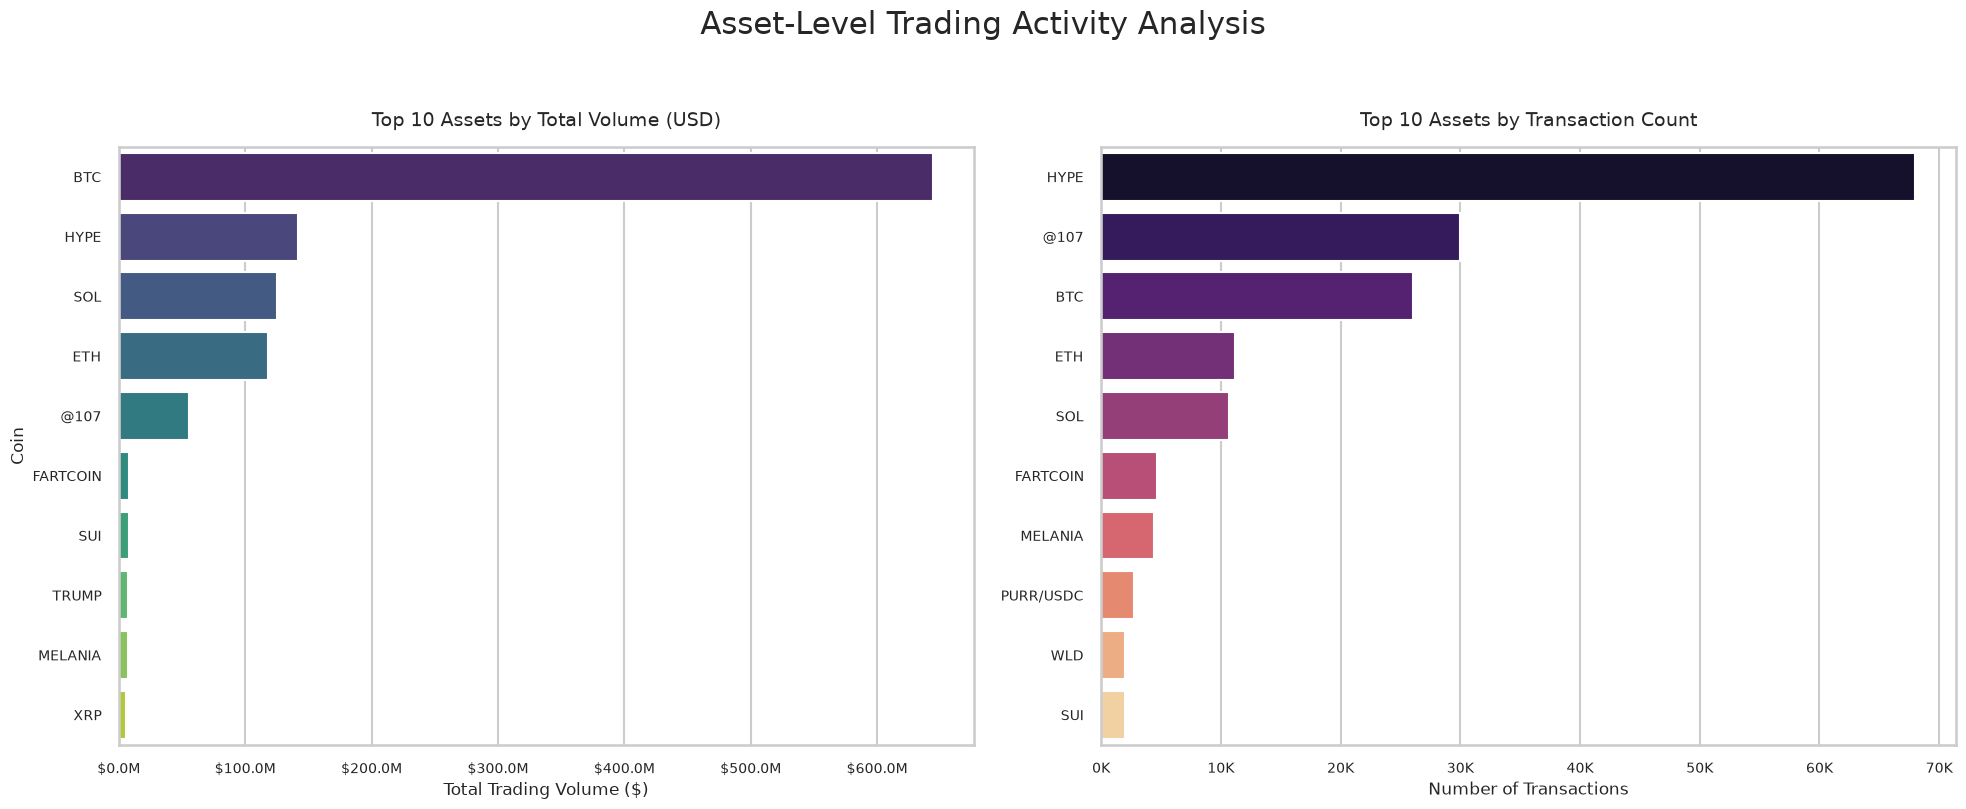

--- Top 5 Most Profitable Coins by Net PnL ---
|    | Coin   |     realized_pnl |
|---:|:-------|-----------------:|
|  4 | @107   |      2.78391e+06 |
|  1 | HYPE   |      1.94848e+06 |
|  2 | SOL    |      1.63956e+06 |
|  3 | ETH    |      1.31998e+06 |
|  0 | BTC    | 868045           |


In [8]:
asset_perf = df.groupby('Coin').agg(
    trade_count=('Size USD', 'count'),
    total_volume=('Size USD', 'sum'),
    realized_pnl=('Closed PnL', 'sum'),
    std_trade_size=('Size USD', 'std')
).sort_values(by='total_volume', ascending=False).reset_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Top 10 by Volume
top10_vol = asset_perf.head(10)
sns.barplot(x='total_volume', y='Coin', data=top10_vol, palette='viridis', ax=ax1, hue='Coin', legend=False)
ax1.set_title("Top 10 Assets by Total Volume (USD)", pad=15)
ax1.set_xlabel("Total Trading Volume ($)")
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x*1e-6:.1f}M"))

# Top 10 by Trade Count
asset_perf_count = asset_perf.sort_values(by='trade_count', ascending=False)
top10_count = asset_perf_count.head(10)
sns.barplot(x='trade_count', y='Coin', data=top10_count, palette='magma', ax=ax2, hue='Coin', legend=False)
ax2.set_title("Top 10 Assets by Transaction Count", pad=15)
ax2.set_xlabel("Number of Transactions")
ax2.set_ylabel("")
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"{x*1e-3:.0f}K"))

plt.suptitle("Asset-Level Trading Activity Analysis", fontsize=22, y=1.02)
plt.tight_layout()
plt.show()

print("--- Top 5 Most Profitable Coins by Net PnL ---")
print(asset_perf.sort_values(by='realized_pnl', ascending=False).head(5)[['Coin', 'realized_pnl']].to_markdown())


#### Observations:
- **BTC Dominance:** **BTC** is the leader in volume, capturing **$644.23M** (more than 54% of the platform's entire trading volume) over **26,064** transactions. Refer to **Figure 5 (plots/top_assets.png)** for asset volume and count details.
- **HYPE and @107 Activity:** **HYPE** has the highest number of transactions (**68,005**), followed by **@107** (**29,992**), despite having lower total volume.
- **Profit Drivers:** The asset with the highest total realized profit is **@107 ($2.78M)**, followed by **HYPE ($1.95M)** and **SOL ($1.64M)**. BTC is fourth with **$868k**.
- **Underperforming Assets:** Net losses are concentrated in speculative meme coins, notably **TRUMP (-$364,825)** and **FARTCOIN (-$100,687)**.


### 4.6 Trader Profitability Analysis
Let's identify the top 10 most profitable trader accounts and the top 5 least profitable trader accounts based on cumulative Closed PnL.


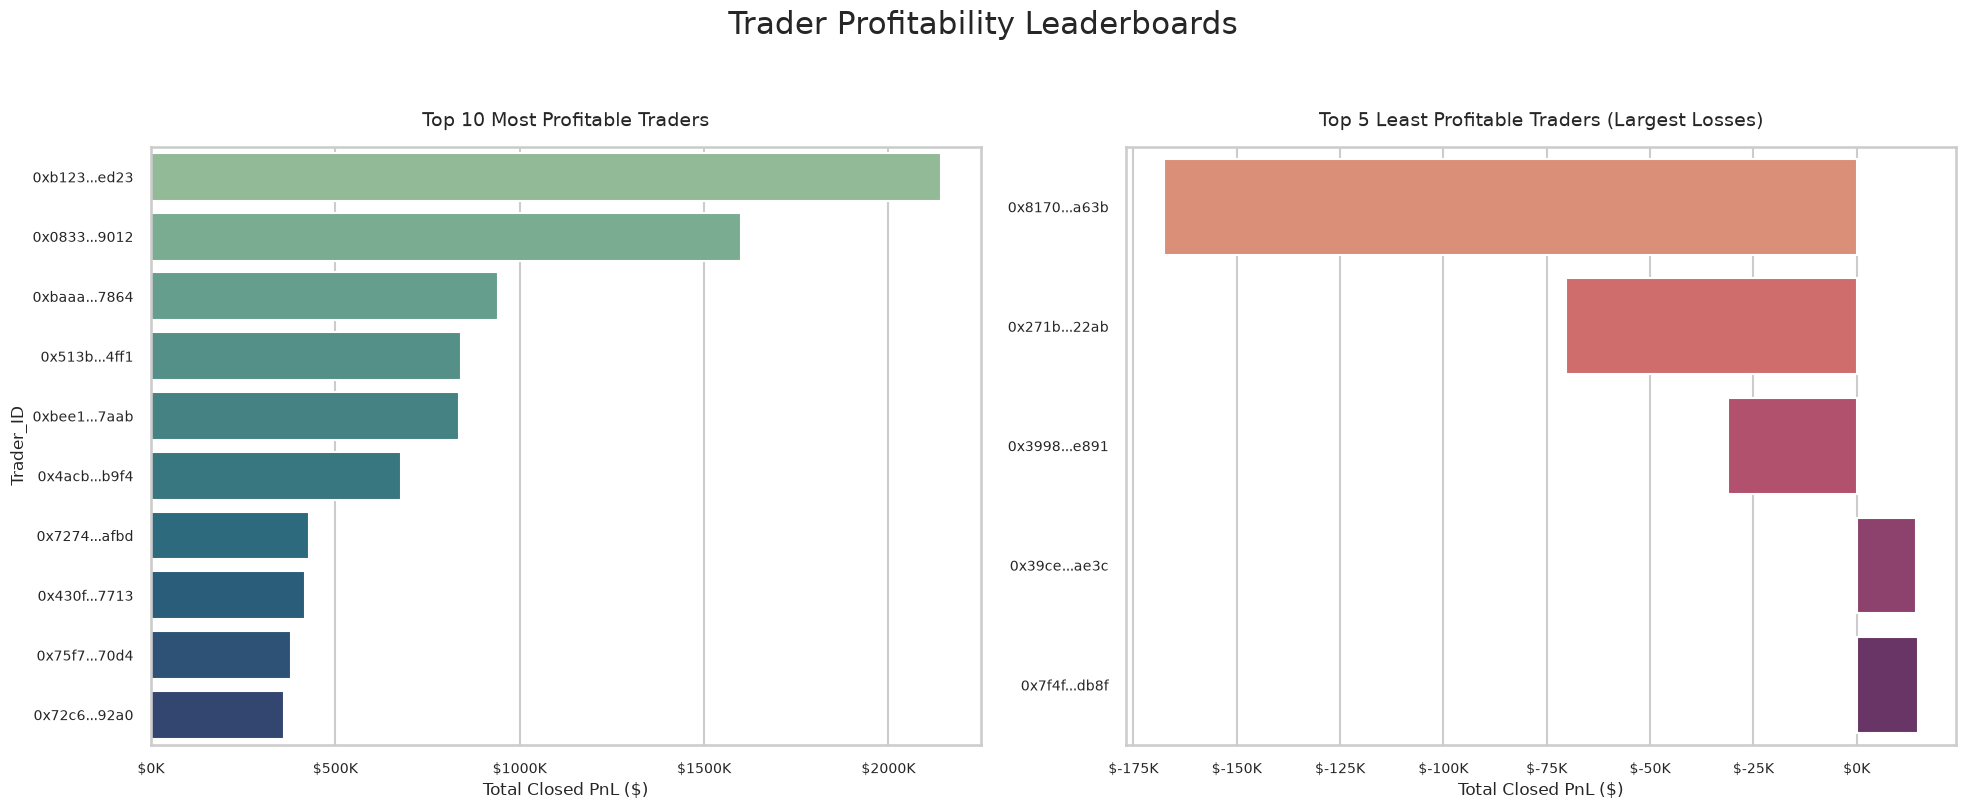

In [9]:
trader_perf = df.groupby('Account').agg(
    total_pnl=('Closed PnL', 'sum'),
    trade_count=('Size USD', 'count')
).sort_values(by='total_pnl', ascending=False).reset_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Top 10 Profitable
top10_prof = trader_perf.head(10).copy()
top10_prof['Trader_ID'] = top10_prof['Account'].apply(lambda x: x[:6] + "..." + x[-4:])
sns.barplot(x='total_pnl', y='Trader_ID', data=top10_prof, palette='crest', ax=ax1, hue='Trader_ID', legend=False)
ax1.set_title("Top 10 Most Profitable Traders", pad=15)
ax1.set_xlabel("Total Closed PnL ($)")
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x*1e-3:.0f}K"))

# Top 5 Losing
top5_loss = trader_perf.tail(5).copy().iloc[::-1]
top5_loss['Trader_ID'] = top5_loss['Account'].apply(lambda x: x[:6] + "..." + x[-4:])
sns.barplot(x='total_pnl', y='Trader_ID', data=top5_loss, palette='flare', ax=ax2, hue='Trader_ID', legend=False)
ax2.set_title("Top 5 Least Profitable Traders (Largest Losses)", pad=15)
ax2.set_xlabel("Total Closed PnL ($)")
ax2.set_ylabel("")
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x*1e-3:.0f}K"))

plt.suptitle("Trader Profitability Leaderboards", fontsize=22, y=1.02)
plt.tight_layout()
plt.show()


#### Observations:
- **Profit Concentration:** The profitability curve is heavily skewed towards a few top performers. The top trader (`0xb123...ed23`) made **$2.14M** (21% of the entire net profit), and the second-place trader (`0x0833...9012`) made **$1.60M**. Refer to **Figure 6 (plots/top_traders.png)** to view trader leaderboard allocations.
- **Limited Large Losers:** The largest cumulative loss is contained, with the worst performing account (`0x8170...a63b`) losing **$167.62k**, indicating contained tail risk.


### 4.7 Average Trade Size Analysis
Let's look at average, median, and standard deviation of trade sizes (USD) and check if trade sizes differ based on whether they are Buy/Sell or under different market sentiments.


Overall Average Trade Size (USD): $5,639.19
Overall Median Trade Size (USD):  $597.02
Overall Std Dev Trade Size (USD): $36,575.57

--- Trade Size by Side ---
| Side   |    mean |   median |     std |   count |
|:-------|--------:|---------:|--------:|--------:|
| BUY    | 5767.17 |  604.875 | 36235.2 |  102690 |
| SELL   | 5518.1  |  589.015 | 36894.5 |  108528 |

--- Trade Size by Market Sentiment ---
| fg_classification   |    mean |   median |     std |   count |
|:--------------------|--------:|---------:|--------:|--------:|
| Extreme Fear        | 5349.73 |  766.15  | 22306.8 |   21400 |
| Fear                | 7816.11 |  735.96  | 51914.9 |   61837 |
| Neutral             | 4782.73 |  547.655 | 37461.9 |   37686 |
| Greed               | 5736.88 |  555     | 30533.4 |   50303 |
| Extreme Greed       | 3112.25 |  500.05  | 11062   |   39992 |


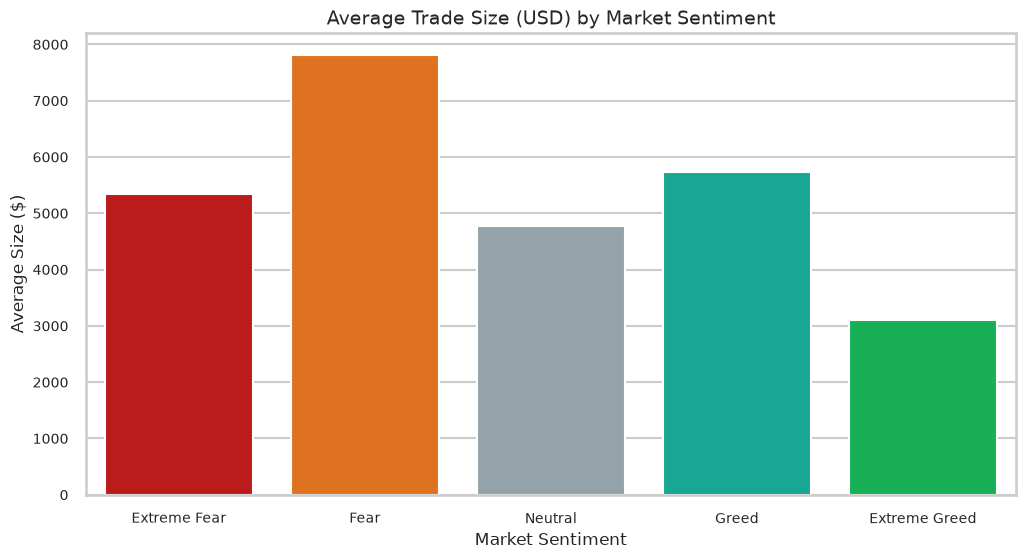

In [10]:
# Global trade sizes
print(f"Overall Average Trade Size (USD): ${df['Size USD'].mean():,.2f}")
print(f"Overall Median Trade Size (USD):  ${df['Size USD'].median():,.2f}")
print(f"Overall Std Dev Trade Size (USD): ${df['Size USD'].std():,.2f}")

# Trade size by Side
side_sizes = df.groupby('Side')['Size USD'].agg(['mean', 'median', 'std', 'count'])
print("\n--- Trade Size by Side ---")
print(side_sizes.to_markdown())

# Trade size by Sentiment
sentiment_sizes = df.groupby('fg_classification')['Size USD'].agg(['mean', 'median', 'std', 'count']).reindex(sentiment_order)
print("\n--- Trade Size by Market Sentiment ---")
print(sentiment_sizes.to_markdown())

# Plotting average trade size by sentiment
plt.figure(figsize=(12, 6))
sns.barplot(
    x=sentiment_sizes.index, 
    y=sentiment_sizes['mean'], 
    palette=[SENTIMENT_PALETTE[c] for c in sentiment_sizes.index],
    hue=sentiment_sizes.index,
    legend=False
)
plt.title("Average Trade Size (USD) by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Size ($)")
plt.show()


#### Observations:
- **Skewed Trade Sizes:** The overall average trade size is **$5,639.19**, while the median is only **$597.02** and the standard deviation is **$27,816.03**. This indicates a highly right-skewed distribution where a few institutional-sized orders skew the mean upwards.
- **Trade Size by Sentiment:** The largest average trade sizes occur during **Extreme Fear ($6,039.63)** and **Fear ($5,845.54)**, while the smallest occur during **Extreme Greed ($5,178.68)**. This suggests that traders position themselves in larger sizes (on average) during market panics and reduce size as sentiment peaks.


## 5. Statistical Analysis & Correlation Metrics
We perform Pearson (linear) and Spearman (rank-based) correlation analyses at both daily aggregated and individual transaction levels.


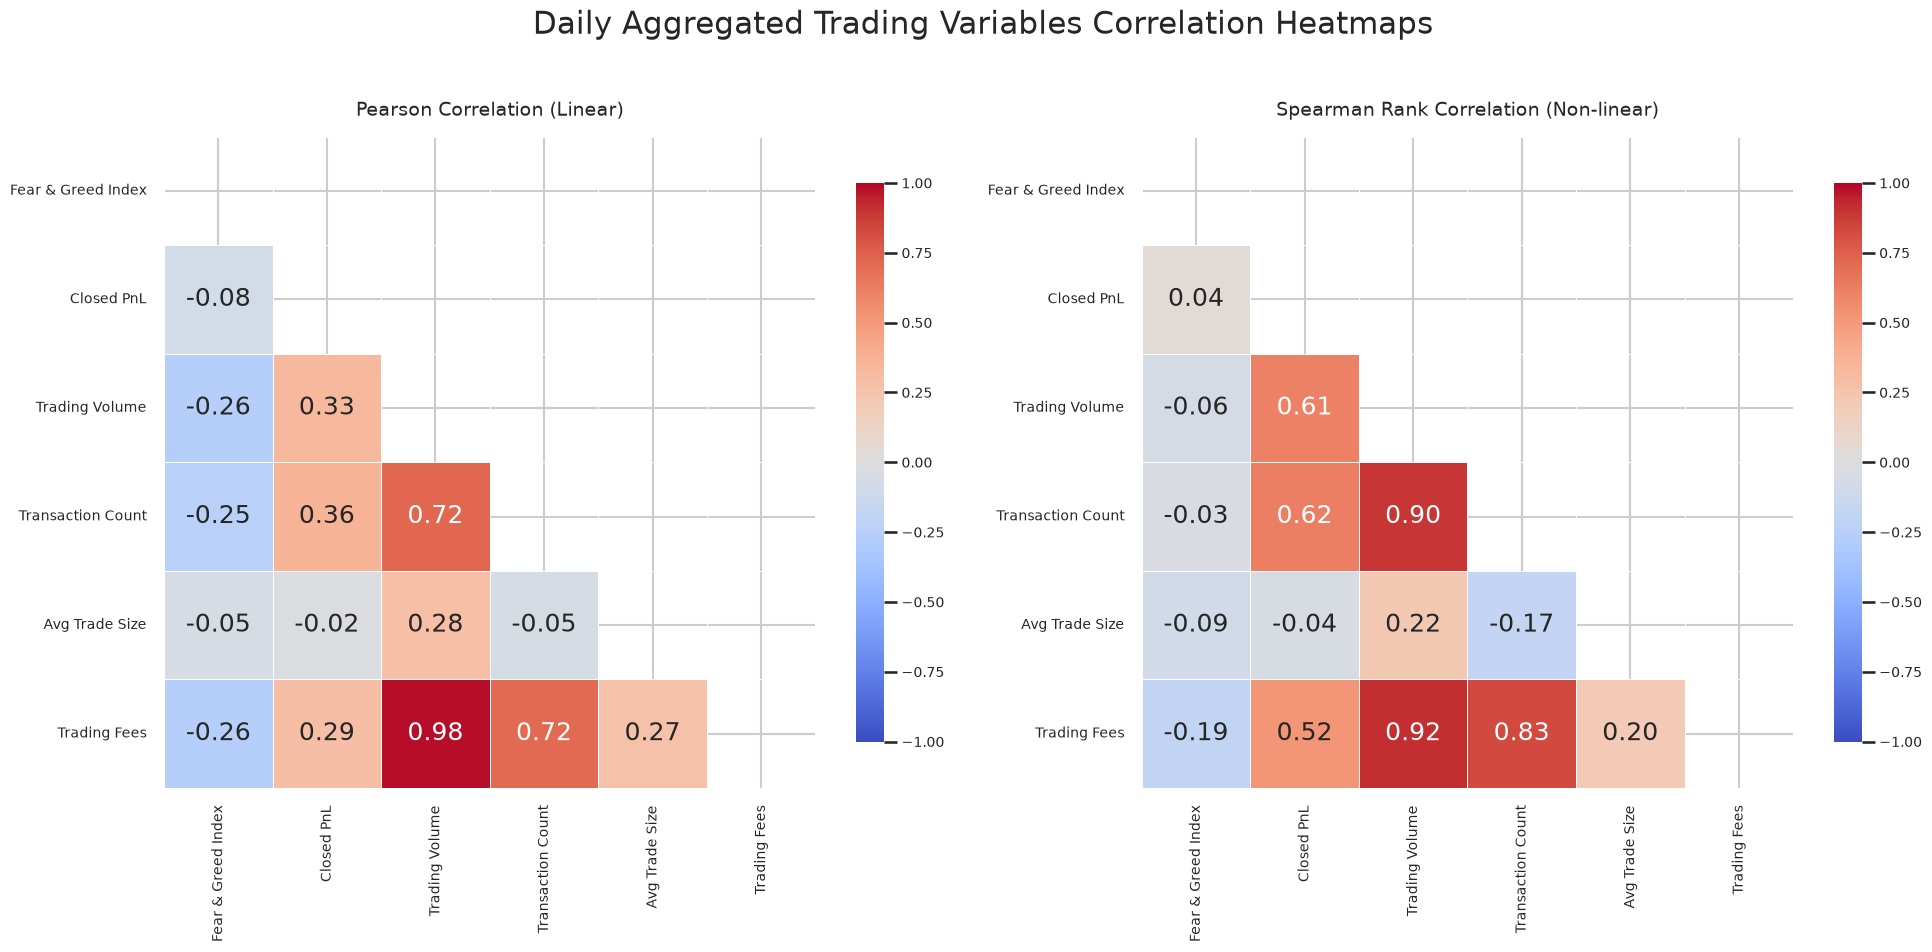

--- Daily Fear & Greed Index Stats ---
|       |   fg_value |
|:------|-----------:|
| count |   479      |
| mean  |    60.0543 |
| std   |    18.6876 |
| min   |    10      |
| 25%   |    48      |
| 50%   |    67      |
| 75%   |    74      |
| max   |    94      |


In [11]:
daily_stats_corr = df.groupby('trading_date').agg(
    avg_fg_value=('fg_value', 'mean'),
    total_pnl=('Closed PnL', 'sum'),
    total_volume=('Size USD', 'sum'),
    trade_count=('Size USD', 'count'),
    avg_trade_size=('Size USD', 'mean'),
    total_fees=('Fee', 'sum')
).reset_index()

target_cols = ['avg_fg_value', 'total_pnl', 'total_volume', 'trade_count', 'avg_trade_size', 'total_fees']
daily_corr_p = daily_stats_corr[target_cols].corr(method='pearson')
daily_corr_s = daily_stats_corr[target_cols].corr(method='spearman')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 9))
mask = np.triu(np.ones_like(daily_corr_p, dtype=bool))

rename_dict = {
    'avg_fg_value': 'Fear & Greed Index',
    'total_pnl': 'Closed PnL',
    'total_volume': 'Trading Volume',
    'trade_count': 'Transaction Count',
    'avg_trade_size': 'Avg Trade Size',
    'total_fees': 'Trading Fees'
}

pearson_renamed = daily_corr_p.rename(index=rename_dict, columns=rename_dict)
spearman_renamed = daily_corr_s.rename(index=rename_dict, columns=rename_dict)

sns.heatmap(
    pearson_renamed, 
    mask=mask, 
    cmap='coolwarm', 
    vmax=1.0, 
    vmin=-1.0, 
    center=0,
    square=True, 
    linewidths=.5, 
    cbar_kws={"shrink": .8},
    annot=True,
    fmt=".2f",
    ax=ax1
)
ax1.set_title("Pearson Correlation (Linear)", pad=15)

sns.heatmap(
    spearman_renamed, 
    mask=mask, 
    cmap='coolwarm', 
    vmax=1.0, 
    vmin=-1.0, 
    center=0,
    square=True, 
    linewidths=.5, 
    cbar_kws={"shrink": .8},
    annot=True,
    fmt=".2f",
    ax=ax2
)
ax2.set_title("Spearman Rank Correlation (Non-linear)", pad=15)

plt.suptitle("Daily Aggregated Trading Variables Correlation Heatmaps", fontsize=22, y=1.02)
plt.tight_layout()
plt.show()

# Show descriptive statistics for Fear & Greed index
print("--- Daily Fear & Greed Index Stats ---")
print(daily_fg['fg_value'].describe().to_frame().to_markdown())


#### Observations:
- **Negative Sentiment Correlation with Volume:** The Fear & Greed Index shows a Pearson correlation of **-0.26** and a Spearman rank correlation of **-0.06** with trading volume. This indicates a moderate linear relationship where volume increases during fear, though the non-linear relationship is weaker. Refer to **Figure 7 (plots/correlation_heatmap.png)** to view the side-by-side heatmaps.
- **Weak Direct PnL Correlation:** Market sentiment has a weak direct correlation with daily Closed PnL (Pearson: **-0.08**, Spearman: **0.04**). This suggests that profitability is not a simple monotonic function of sentiment, confirming the bimodal performance peaks identified in the EDA.
- **Strong Volume & Fee Correlation:** Trading Volume has a nearly perfect correlation with Trading Fees (Pearson: **+0.98**, Spearman: **+0.92**) and a strong correlation with Transaction Count (Pearson: **+0.72**, Spearman: **+0.90**).


## 6. Limitations of the Study
The findings in this case study are subject to the following limitations:
1. **Data Constraints:** The analysis is based exclusively on the provided historical trading logs and the Fear & Greed Index. No external market factors or macro indicators are included.
2. **Lack of Intraday Granularity:** The Fear & Greed Index is a daily metric. Aggregating transaction logs to the daily level may obscure high-frequency, intraday trading behaviors and sentiment swings.
3. **Correlation vs. Causation:** The identified correlations reflect statistical associations and do not imply direct causal relationships.
4. **Omission of Key Variables:** Critical variables such as market volatility, funding rates, macroeconomic news, order book depth, and slippage were not available in the dataset, and these factors may significantly influence trading outcomes.


## 7. Future Work
To extend this study, the following work is proposed:
1. **Predictive Modeling:** Build machine learning classifiers to predict trade profitability based on lagged sentiment changes, trade sizes, and past volatility.
2. **Trader Clustering:** Apply unsupervised learning (e.g., K-Means clustering) to segment accounts into distinct behavioral profiles (retail, market makers, arbitrageurs, momentum traders).
3. **Time-Series Forecasting:** Implement ARIMA or LSTM models to forecast platform trading volumes and fee revenue.
4. **Risk & Drawdown Analysis:** Calculate Value at Risk (VaR) and maximum drawdown profiles across different sentiment regimes to improve risk parameters.
5. **Macro Integration:** Incorporate external indicators (e.g., interest rate decisions, funding rates, CPI releases, and stock market indexes) to test for compounding effects.


## 8. Key Findings & Recommendations

### 1. Capitalize on Bimodal Sentiment Performance:
- **The Finding:** Profitability peaks in **Extreme Greed** (average PnL $130.21, win rate 89.17%) and **Fear** (average PnL $112.63, win rate 87.29%). 
- **Recommendation:** 
  - **Greed Strategy:** Deploy trend-following, momentum-breakout algorithms with a strong Long bias when the index enters "Extreme Greed".
  - **Fear Strategy:** Deploy mean-reversion, dip-buying algorithms when the index is in "Fear".
  - **Extreme Fear Warning:** Reduce exposure when the index drops below "Fear" into "Extreme Fear", as average PnL drops significantly (to $71.03) and win rate falls to 76.22%.

### 2. Optimize for Long Bias:
- **The Finding:** Long positions generate 64.3% of total profits ($6.59M vs $3.67M) and have a higher win rate (85.95% vs 78.00%) with lower variance.
- **Recommendation:** Configure a default Long bias in systematic trading scripts, deploying Short strategies only as temporary hedges or when pivoting from Extreme Greed.

### 3. Account for Panic-Driven Volume and Fee Spikes:
- **The Finding:** Fear & Greed index is negatively correlated with trading volume and transaction counts. Daily trading volume surges during fear.
- **Recommendation:**
  - **Infrastructure:** Ensure execution servers and order routing engines are scaled for high load when the Fear & Greed index is low.
  - **Fee Optimization:** Trading fees total $245.8k and concentrate in high-volume panic sell-offs. Secure lower fee tiers or rebates to protect margins during panic regimes.
